# 🚗 Vehicle Tax – PRODUCTION RUN
## กรมการขนส่งทางบก | Full Dataset | Best Params (No Tuning)

> **Notebook นี้รัน 7 โมเดลด้วย Best Params จาก Quick Run โดยตรง**  
> ไม่มี Optuna, ไม่มี EDA, ไม่มี K-Means — เฉพาะ Pipeline → Model → SHAP → Export

| | |
|---|---|
| **Data** | `Merge_clean.csv` (Full ~1M records) |
| **Split** | Rolling-Window: Train ≤ 2022 \| Test 2023+ |
| **Models** | LogReg · RF · XGBoost · MLP · CNN · RNN · LSTM |
| **Output** | `model_metrics.csv` · `best_params.json` · `high_risk_taxpayers.csv` · `shap_summary.png` |

⚠️ **ก่อนรัน:** เปลี่ยน `DATA_PATH` ให้ชี้ไปที่ไฟล์เต็มของคุณ


## ⚙️ 0. Install & Import

In [1]:
# รัน cell นี้ครั้งเดียว แล้ว Runtime → Restart
import subprocess, sys
for pkg in ["xgboost","shap","optuna","plotly","kaleido"]:
    subprocess.run([sys.executable,"-m","pip","install",pkg,"-q"], check=False)
print("✅ Done")


✅ Done


In [2]:
# ─── Core Imports ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings, os, requests
warnings.filterwarnings("ignore")

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              f1_score, classification_report,
                              average_precision_score, silhouette_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

import xgboost as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.utils import set_random_seed as keras_seed
keras_seed(42)
tf.random.set_seed(42)
np.random.seed(42)

print(f"✅ TensorFlow {tf.__version__} | XGBoost {xgb.__version__}")


✅ TensorFlow 2.20.0 | XGBoost 3.2.0


In [3]:
# ─── 🎨 DLT Brand Theme: ม่วง + ทอง ──────────────────────────────────────────
# กรมการขนส่งทางบก Color Palette
DLT = dict(
    purple_deep   = "#2D1B69",   # ม่วงเข้มมาก
    purple_main   = "#5B2D8E",   # ม่วงหลัก
    purple_mid    = "#7B52AB",   # ม่วงกลาง
    purple_light  = "#C4A8E8",   # ม่วงอ่อน
    gold_main     = "#C8A84B",   # ทองหลัก
    gold_bright   = "#FFD700",   # ทองสว่าง
    gold_light    = "#F5E6A3",   # ทองอ่อน
    bg_dark       = "#1A0A3C",   # พื้นหลังเข้ม
    bg_card       = "#2C1654",   # card background
    white         = "#FFFFFF",
    gray_soft     = "#E8E0F5",
)

# ─── Download & Register Google Kanit Font ────────────────────────────────────
KANIT_URL = "https://fonts.gstatic.com/s/kanit/v15/nKKZ-Go6G5tXcoaPWg.woff2"
KANIT_TTF = "https://github.com/google/fonts/raw/main/ofl/kanit/Kanit-Regular.ttf"
KANIT_PATH = "/tmp/Kanit-Regular.ttf"

try:
    if not os.path.exists(KANIT_PATH):
        r = requests.get(KANIT_TTF, timeout=15)
        r.raise_for_status()
        with open(KANIT_PATH,"wb") as f: f.write(r.content)
    fm.fontManager.addfont(KANIT_PATH)
    THAI_FONT = "Kanit"

    # Bold variant
    KANIT_BOLD_URL = "https://github.com/google/fonts/raw/main/ofl/kanit/Kanit-SemiBold.ttf"
    KANIT_BOLD_PATH = "/tmp/Kanit-SemiBold.ttf"
    if not os.path.exists(KANIT_BOLD_PATH):
        r2 = requests.get(KANIT_BOLD_URL, timeout=15)
        r2.raise_for_status()
        with open(KANIT_BOLD_PATH,"wb") as f: f.write(r2.content)
    fm.fontManager.addfont(KANIT_BOLD_PATH)
    print("✅ Kanit font (Regular + SemiBold) loaded")
except Exception as e:
    THAI_FONT = "DejaVu Sans"
    print(f"⚠️  Kanit not loaded ({e}) – ใช้ DejaVu Sans")

matplotlib.rcParams.update({
    "font.family"    : THAI_FONT,
    "axes.titlesize" : 13,
    "axes.labelsize" : 11,
    "legend.fontsize": 10,
    "figure.dpi"     : 130,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
})
sns.set_style("whitegrid")

# Plotly DLT Template
dlt_layout = dict(
    paper_bgcolor = DLT["bg_dark"],
    plot_bgcolor  = DLT["bg_card"],
    font          = dict(family=THAI_FONT, color=DLT["white"], size=12),
    title_font    = dict(family=THAI_FONT, color=DLT["gold_main"], size=16),
    legend        = dict(bgcolor=DLT["bg_card"], bordercolor=DLT["gold_main"], borderwidth=1),
    xaxis         = dict(gridcolor="#3D2080", tickfont=dict(color=DLT["white"])),
    yaxis         = dict(gridcolor="#3D2080", tickfont=dict(color=DLT["white"])),
)

RANDOM_STATE = 42
TRAIN_CUTOFF = 2022     # Rolling-Window: train ≤ 2022, test 2023+
SEQ_LEN      = 4        # ความยาว sequence สำหรับ LSTM/RNN/CNN
print("✅ DLT Theme & Config ready")
print(f"   Rolling-Window Cutoff : Due_Year ≤ {TRAIN_CUTOFF} = Train | > {TRAIN_CUTOFF} = Test")
print(f"   Sequence Length (LSTM): {SEQ_LEN} ปี")


# ─── ax_style helper (global – ใช้ได้ทุก cell) ───────────────────────────────
def ax_style(ax, title="", xticks_rot=0):
    ax.set_facecolor(DLT["bg_card"])
    for spine in ax.spines.values():
        spine.set_edgecolor(DLT["purple_mid"])
    ax.tick_params(colors=DLT["white"], labelsize=9)
    ax.xaxis.label.set_color(DLT["white"])
    ax.yaxis.label.set_color(DLT["white"])
    if title:
        ax.set_title(title, color=DLT["gold_main"],
                     fontsize=11, pad=8, fontweight="bold")
    if xticks_rot:
        ax.tick_params(axis="x", rotation=xticks_rot)
    ax.grid(color=DLT["purple_light"], alpha=0.15, linewidth=0.6)


# ─── QUICK_MODE: สลับ True/False ตามต้องการ ────────────────────────────────────
QUICK_MODE    = False   # ← PRODUCTION: ใช้ข้อมูลเต็ม
QUICK_N       = 5_000   # ไม่ใช้ใน production
QUICK_TRIALS  = 5       # Optuna trials ใน quick mode
QUICK_EPOCHS  = 20      # Keras epochs ใน quick mode
PROD_TRIALS   = 50      # Optuna trials ใน production
PROD_EPOCHS   = 80      # Keras epochs ใน production

N_OPTUNA = QUICK_TRIALS if QUICK_MODE else PROD_TRIALS
N_EPOCHS  = QUICK_EPOCHS if QUICK_MODE else PROD_EPOCHS

print(f"Mode: {'QUICK (sample)' if QUICK_MODE else 'PRODUCTION (full data)'}")
print(f"  Optuna trials : {N_OPTUNA}")
print(f"  Keras epochs  : {N_EPOCHS}")


✅ Kanit font (Regular + SemiBold) loaded
✅ DLT Theme & Config ready
   Rolling-Window Cutoff : Due_Year ≤ 2022 = Train | > 2022 = Test
   Sequence Length (LSTM): 4 ปี
Mode: PRODUCTION (full data)
  Optuna trials : 50
  Keras epochs  : 80


## 📥 1. Load Data

In [4]:
# ─── Load Data ────────────────────────────────────────────────────────────────
# Google Colab: อัพโหลด Merge_clean_sample.csv แล้วระบุ path ด้านล่าง
# Option B: Google Drive
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/My Drive/4. Econ Master Project/4. Semester 4_Spring 2026/Data in IO/Final Project/Data/Merge/Merge_clean.csv'


df_raw = pd.read_csv(DATA_PATH, low_memory=False)

# เก็บเฉพาะแถวที่มี Status (แถวที่มี match ทั้ง 2 ปี)
df_raw = df_raw[df_raw["Status"].notna()].copy()
print(f"📊 Working dataset: {len(df_raw):,} rows × {df_raw.shape[1]} cols")
print(f"   Unique vehicles : {df_raw['Encode_ChassisNo'].nunique():,}")
print(f"   Due_Year range  : {df_raw['Due_Year'].min():.0f} – {df_raw['Due_Year'].max():.0f}")


# ─── สร้าง df จาก df_raw + ปรับชื่อคอลัมน์ ──────────────────────────────────
df = df_raw.copy()

# Rename Sheet1.* → ตัด prefix ออก (ยกเว้น Payment_Chanel ที่ชนกับ top-level)
rename_map = {}
for col in df.columns:
    if col.startswith('Sheet1.'):
        new_name = col.replace('Sheet1.', '')
        # Payment_Chanel มีทั้ง top-level (ปีนี้) และ Sheet1. (ปีก่อน) → เพิ่ม _last
        if new_name in df.columns:
            new_name = new_name + '_last'
        rename_map[col] = new_name
df.rename(columns=rename_map, inplace=True)

print(f"✅ df พร้อมใช้งาน | {len(df):,} rows × {df.shape[1]} cols")
print(f"   ตัวอย่างคอลัมน์ที่ rename: {list(rename_map.values())[:6]} ...")


Mounted at /content/drive
📊 Working dataset: 972,203 rows × 45 cols
   Unique vehicles : 99,975
   Due_Year range  : 1973 – 2026
✅ df พร้อมใช้งาน | 972,203 rows × 45 cols
   ตัวอย่างคอลัมน์ที่ rename: ['Province_last_year', 'Vehicle_Age_lastyear', 'Exp_Date', 'Exp_Year', 'Payment_Date_Last', 'Payment_Status'] ...


## 🔧 2. Feature Engineering & Cleansing
*(โค้ดเหมือน Development Notebook ทุกอย่าง)*

In [5]:
# ─── 2) Days_Diff_Payment: payment date - due date ────────────────────────────
payment_dt = pd.to_datetime(df['Payment_Date'], dayfirst=True, errors='coerce')
due_dt     = pd.to_datetime(df['Due_Date'],     dayfirst=True, errors='coerce')
df['Days_Diff_Payment'] = (payment_dt - due_dt).dt.days
# Fill missing from Status label
fill_map = {'จ่ายก่อน': -15, 'จ่ายตรง': 0, 'จ่ายช้า': 60}
df['Days_Diff_Payment'] = df['Days_Diff_Payment'].fillna(df['Status'].map(fill_map))
print(f"Days_Diff_Payment | min={df['Days_Diff_Payment'].min():.0f}, max={df['Days_Diff_Payment'].max():.0f}")

# ─── 3) Target: Is_Late ───────────────────────────────────────────────────────
df['Target_Is_Late'] = (df['Status'] == 'จ่ายช้า').astype(int)
print(f"Target_Is_Late | Late Rate = {df['Target_Is_Late'].mean()*100:.1f}%")

# ─── 4) Cross_Province_Payment ───────────────────────────────────────────────
reg_prov = 'Province'
pay_prov = 'Payment_Province'
df['Cross_Province_Payment'] = (df[reg_prov].str.strip() != df[pay_prov].str.strip()).astype(int)
print(f"Cross_Province_Payment | {df['Cross_Province_Payment'].mean()*100:.1f}% ต่างจังหวัด")

# ─── 5) Owner_Age (Upgraded for Panel Data) ──────────────────────────────────
if 'Owner_Birth_Date' in df.columns:
    birth_dt = pd.to_datetime(df['Owner_Birth_Date'], dayfirst=True, errors='coerce')

    # 🌟 แกะสมการใหม่: เอา Due_Year ของ "แถวนั้นๆ" มาลบกับปีเกิดเลย ไม่อิง Median
    if 'Due_Year' in df.columns:
        df['Owner_Age'] = (df['Due_Year'] - birth_dt.dt.year)
    else:
        # เผื่อกรณีไม่มี Due_Year ให้ใช้ปีปัจจุบันแทน
        df['Owner_Age'] = (2024 - birth_dt.dt.year)

    # ตัดขอบเขต (Clip) ไม่ให้อายุเพี้ยน และถ้าคำนวณไม่ได้ (NaN) ให้เติมด้วย 45
    df['Owner_Age'] = df['Owner_Age'].clip(18, 90).fillna(45)
else:
    df['Owner_Age'] = 45

print(f"Owner_Age | mean={df['Owner_Age'].mean():.0f} ปี")

# ─── 6) Is_Urban (Refined Version) ───────────────────────────────────────────

# 1. กลุ่มจังหวัดปริมณฑล (ถือเป็นเขตเมืองทั้งหมด)
BKK_METRO = ['กรุงเทพมหานคร', 'นนทบุรี', 'ปทุมธานี', 'สมุทรปราการ']

# 2. กลุ่มอำเภอเศรษฐกิจขนาดใหญ่ (ที่มีความเป็น Urban สูงมาก แต่ไม่ใช่อำเภอเมือง)
MAJOR_DISTRICTS = [
    'หาดใหญ่', 'บางละมุง', 'ศรีราชา', 'สัตหีบ', # ชลบุรี/สงขลา
    'หัวหิน', 'ชะอำ', 'ปราณบุรี',              # ประจวบฯ/เพชรบุรี
    'แม่สอด', 'ปากช่อง', 'กะทู้', 'ถลาง',      # ตาก/โคราช/ภูเก็ต
    'เกาะสมุย', 'แม่สาย'                     # สุราษฎร์ฯ/เชียงราย
]

def define_urban(row):
    # ดึงค่าจังหวัดและที่อยู่มาเช็ค (กัน Error ค่าว่างด้วย str())
    prov = str(row.get('Owner_Province', row.get('Province', '')))
    loc = str(row.get('Owner_Location', ''))

    # เงื่อนไข 1: อยู่ใน กทม. และปริมณฑล -> เป็น Urban ทันที
    if prov in BKK_METRO:
        return 1

    # เงื่อนไข 2: มีคำว่า "อำเภอเมือง" หรือ "อ.เมือง" ในที่อยู่
    if 'อำเภอเมือง' in loc or 'อ.เมือง' in loc:
        return 1

    # เงื่อนไข 3: อยู่ในอำเภอเศรษฐกิจขนาดใหญ่ที่ลิสต์ไว้
    if any(dist in loc for dist in MAJOR_DISTRICTS):
        return 1

    # # เงื่อนไข 4 (Optional): มีคำว่า "เทศบาลนคร" หรือ "เทศบาลเมือง" (ดักจับคนในเขตชุมชนเมืองของจังหวัดเล็กๆ)
    # if 'เทศบาลนคร' in loc or 'เทศบาลเมือง' in loc:
    #     return 1

    # ถ้านอกเหนือจากนี้ ถือว่าเป็นชนบท (Rural)
    return 0

# Apply ฟังก์ชันลงไปใน DataFrame
df['Is_Urban'] = df.apply(define_urban, axis=1)

print(f"Is_Urban (Refined) | {df['Is_Urban'].mean()*100:.1f}% เขตเมือง")

# ─── 7) Vehicle_Age ───────────────────────────────────────────────────────────
if 'Vehicle_Age' not in df.columns:
    df['Vehicle_Age'] = df.get('Exp_Vehicle_Age', pd.Series([5]*len(df)))
df['Vehicle_Age'] = pd.to_numeric(df['Vehicle_Age'], errors='coerce').fillna(5)

# ─── 8) Payment channel flags ────────────────────────────────────────────────
ch = df['Payment_Chanel'] if 'Payment_Chanel' in df.columns else df.get('Payment_Channel', pd.Series(['สำนักงานขนส่ง']*len(df)))
df['Is_Digital_Payment']      = ch.isin(['ธนาคาร','ไปรษณีย์','เว็บไซต์','แอปพลิเคชัน']).astype(int)
df['Is_Mobile_Unit']          = (ch == 'ออกหน่วยเคลื่อนที่').astype(int)
df['Is_Cross_Province_Channel']= ch.str.contains('ต่างภูมิลำเนา|นอกเขต', na=False).astype(int)

# ─── 9) Penalty flag ─────────────────────────────────────────────────────────
pen_col = 'Pen_Amount' if 'Pen_Amount' in df.columns else None
if pen_col:
    df['Pen_Amount']  = pd.to_numeric(df[pen_col], errors='coerce').fillna(0)
    df['Has_Penalty'] = (df['Pen_Amount'] > 0).astype(int)
else:
    df['Has_Penalty'] = 0

# ─── 10) Engine CC numeric ───────────────────────────────────────────────────
if 'Engine_CC' in df.columns:
    df['Engine_CC'] = pd.to_numeric(df['Engine_CC'], errors='coerce')

print("\n✅ Feature Engineering เสร็จสมบูรณ์!")
new_feats = ['Days_Diff_Payment','Target_Is_Late','Cross_Province_Payment',
             'Owner_Age','Is_Urban','Vehicle_Age','Is_Digital_Payment','Has_Penalty']
display(df[new_feats].describe().round(2))

# ─── 11) Data Cleansing (ลบ Outliers ก่อนนำไปใช้งานจริง) ─────────────────────

# 1. จัดการอายุรถที่ผิดปกติ (พ.ศ. ปน ค.ศ. หรือพิมพ์ผิด)
df = df[(df['Vehicle_Age'] >= 0) & (df['Vehicle_Age'] <= 60)]

# 2. จัดการ Days_Diff_Payment ที่ผิดปกติ (อิงตามกฎหมายขนส่ง จ่ายล่วงหน้าไม่เกิน 90 วัน, ขาดต่อไม่เกิน 3 ปี)
df = df[(df['Days_Diff_Payment'] >= -90) & (df['Days_Diff_Payment'] <= 1095)]

print(f"\n✅ Data Cleansing เสร็จสมบูรณ์! ข้อมูลพร้อมใช้งาน: {len(df):,} เรคคอร์ด")

# ─── เช็คความเรียบร้อย ────────────────────────────────────────────────────────
bad_age_count = df[df['Vehicle_Age'] < 0].shape[0]
print(f"มีรถอายุติดลบทั้งหมด: {bad_age_count:,} คัน")

new_feats = ['Days_Diff_Payment','Target_Is_Late','Cross_Province_Payment',
             'Owner_Age','Is_Urban','Vehicle_Age','Is_Digital_Payment','Has_Penalty']
display(df[new_feats].describe().round(2))
# ─── 12) Lag Features จากปีก่อน (ใช้ Sheet1.* ที่ rename แล้ว) ──────────────
# Payment_Status = Sheet1.Payment_Status (last year status)
if 'Payment_Status' in df.columns:
    df['Last_Is_Late']  = (df['Payment_Status'] == 'จ่ายช้า').astype(int)
    df['Last_Is_Early'] = (df['Payment_Status'] == 'จ่ายก่อน').astype(int)
else:
    df['Last_Is_Late']  = 0
    df['Last_Is_Early'] = 0

# Last_Days_Diff: Payment_Date_Last - Exp_Date (last year due ≈ expiry)
if 'Payment_Date_Last' in df.columns and 'Exp_Date' in df.columns:
    lp_dt   = pd.to_datetime(df['Payment_Date_Last'], dayfirst=True, errors='coerce')
    ldue_dt = pd.to_datetime(df['Exp_Date'],          dayfirst=True, errors='coerce')
    df['Last_Days_Diff'] = (lp_dt - ldue_dt).dt.days
    df['Last_Days_Diff'] = df['Last_Days_Diff'].fillna(
        df['Last_Is_Late'].map({0: -15, 1: 60}))
else:
    df['Last_Days_Diff'] = df['Last_Is_Late'].map({0: -15, 1: 60})

# Last_Tax_Amount (last year tax for trend feature)
if 'Tax_Amount_last' in df.columns:
    df['Last_Tax_Amount'] = pd.to_numeric(df['Tax_Amount_last'], errors='coerce').fillna(0)
else:
    df['Last_Tax_Amount'] = 0

# Tax_Amount numeric
df['Tax_Amount'] = pd.to_numeric(df.get('Tax_Amount', 0), errors='coerce').fillna(0)

print(f"Last_Is_Late  | Late-last-year rate = {df['Last_Is_Late'].mean()*100:.1f}%")
print(f"Last_Days_Diff| mean={df['Last_Days_Diff'].mean():.1f} days")
print("✅ Lag features created")


Days_Diff_Payment | min=-5844, max=11053
Target_Is_Late | Late Rate = 47.8%
Cross_Province_Payment | 26.7% ต่างจังหวัด
Owner_Age | mean=44 ปี
Is_Urban (Refined) | 42.5% เขตเมือง

✅ Feature Engineering เสร็จสมบูรณ์!


,Days_Diff_Payment,Target_Is_Late,Cross_Province_Payment,Owner_Age,Is_Urban,Vehicle_Age,Is_Digital_Payment,Has_Penalty
count,972203.00,972203.00,972203.00,972203.00,972203.00,972203.00,972203.00,972203.00
mean,47.34,0.48,0.27,43.99,0.43,8.54,0.01,0.45
std,163.19,0.50,0.44,13.00,0.49,6.96,0.11,0.50
min,-5844.00,0.00,0.00,18.00,0.00,-28.00,0.00,0.00
25%,-7.00,0.00,0.00,34.00,0.00,3.00,0.00,0.00
50%,0.00,0.00,0.00,44.00,0.00,7.00,0.00,0.00
75%,31.00,1.00,1.00,53.00,1.00,12.00,0.00,1.00
max,11053.00,1.00,1.00,90.00,1.00,69.00,1.00,1.00



✅ Data Cleansing เสร็จสมบูรณ์! ข้อมูลพร้อมใช้งาน: 970,216 เรคคอร์ด
มีรถอายุติดลบทั้งหมด: 0 คัน


,Days_Diff_Payment,Target_Is_Late,Cross_Province_Payment,Owner_Age,Is_Urban,Vehicle_Age,Is_Digital_Payment,Has_Penalty
count,970216.00,970216.00,970216.00,970216.00,970216.00,970216.00,970216.00,970216.00
mean,45.47,0.48,0.27,43.99,0.42,8.54,0.01,0.45
std,138.72,0.50,0.44,13.01,0.49,6.93,0.11,0.50
min,-90.00,0.00,0.00,18.00,0.00,0.00,0.00,0.00
25%,-7.00,0.00,0.00,34.00,0.00,3.00,0.00,0.00
50%,0.00,0.00,0.00,44.00,0.00,7.00,0.00,0.00
75%,31.00,1.00,1.00,53.00,1.00,12.00,0.00,1.00
max,1095.00,1.00,1.00,90.00,1.00,60.00,1.00,1.00


Last_Is_Late  | Late-last-year rate = 35.1%
Last_Days_Diff| mean=-342.3 days
✅ Lag features created


## 📐 3. Tax Behavior Segmentation (4 กลุ่ม)

In [6]:
# ─── Tax Behavior Segmentation – 4 กลุ่ม (ใช้ Days_Diff_Payment) ─────────────
import numpy as np

cut_off_date = pd.Timestamp('2024-12-31')

# ── Days_Late_Actual ──────────────────────────────────────────────────────────
if not pd.api.types.is_datetime64_any_dtype(df['Due_Date']):
    df['Due_Date'] = pd.to_datetime(df['Due_Date'], dayfirst=True, errors='coerce')
if not pd.api.types.is_datetime64_any_dtype(df['Payment_Date']):
    df['Payment_Date'] = pd.to_datetime(df['Payment_Date'], dayfirst=True, errors='coerce')

df['Days_Late_Actual'] = np.where(
    df['Payment_Date'].notnull(),
    (df['Payment_Date'] - df['Due_Date']).dt.days,
    (cut_off_date - df['Due_Date']).dt.days
)

# ── 4 กลุ่มหลัก ───────────────────────────────────────────────────────────────
choices_4 = [
    '1. จ่ายตรงเวลา/ล่วงหน้า',
    '2. จ่ายล่าช้า (≤1 ปี)',
    '3. จ่ายล่าช้า (1-3 ปี)',
    '4. ขาดต่อเกิน 3 ปี',
]
conditions_4 = [
    df['Days_Late_Actual'] <= 0,
    (df['Days_Late_Actual'] > 0)   & (df['Days_Late_Actual'] <= 365),
    (df['Days_Late_Actual'] > 365) & (df['Days_Late_Actual'] <= 1095),
    df['Days_Late_Actual'] > 1095,
]
df['Tax_Behavior_Segment'] = np.select(conditions_4, choices_4, default='Unknown')

seg_code_map = {
    '1. จ่ายตรงเวลา/ล่วงหน้า': 1,
    '2. จ่ายล่าช้า (≤1 ปี)':   2,
    '3. จ่ายล่าช้า (1-3 ปี)':  3,
    '4. ขาดต่อเกิน 3 ปี':      4,
    'Unknown':                   0,
}
df['Seg_Code'] = df['Tax_Behavior_Segment'].map(seg_code_map)

# ── อัพเดต Binary Target ให้ consistent ──────────────────────────────────────
# Binary: 0 = กลุ่ม 1 (ตรงเวลา) | 1 = กลุ่ม 2-4 (ล่าช้าทุกรูปแบบ)
df['Target_Is_Late'] = (df['Seg_Code'] >= 2).astype(int)

# ── Late Severity (ย่อยกลุ่ม 2-3 เพื่อ Nudge ละเอียด) ───────────────────────
df['Late_Severity'] = pd.cut(
    df['Days_Late_Actual'].clip(-90, 1095),
    bins  = [-91, 0, 30, 90, 180, 365, 730, 1095],
    labels= ['ตรงเวลา/ก่อน','ช้า ≤30วัน','ช้า 31-90วัน',
             'ช้า 91-180วัน','ช้า 181-365วัน','ค้าง 1-2ปี','ค้าง 2-3ปี']
)

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 60)
print("    Tax Behavior Segmentation – 4 กลุ่ม")
print("=" * 60)
seg_summary = (df['Tax_Behavior_Segment']
               .value_counts().sort_index()
               .reset_index()
               .rename(columns={'count':'จำนวน','Tax_Behavior_Segment':'กลุ่ม'}))
seg_summary['สัดส่วน (%)'] = (seg_summary['จำนวน'] / len(df) * 100).round(2)
display(seg_summary)

print(f"\nBinary Target_Is_Late rate: {df['Target_Is_Late'].mean()*100:.1f}%")
print(f"Multiclass Seg_Code distribution:")
print(df['Seg_Code'].value_counts().sort_index().to_string())


    Tax Behavior Segmentation – 4 กลุ่ม


,กลุ่ม,จำนวน,สัดส่วน (%)
0,1. จ่ายตรงเวลา/ล่วงหน้า,506645,52.22
1,2. จ่ายล่าช้า (≤1 ปี),423210,43.62
2,3. จ่ายล่าช้า (1-3 ปี),40361,4.16



Binary Target_Is_Late rate: 47.8%
Multiclass Seg_Code distribution:
Seg_Code
1    506645
2    423210
3     40361


## 🔁 4. Feature Sets · Rolling-Window Split · Eval Helpers

In [7]:
# ─── Feature Sets – Pre-Payment Only (no leakage) ────────────────────────────
NUM_FEATS = [f for f in [
    "Vehicle_Age","Owner_Age",
    "Last_Is_Late","Last_Is_Early","Last_Days_Diff","Last_Tax_Amount",
    "Tax_Amount","Engine_CC","No_Seats","Hourse_Power",
] if f in df.columns]

BIN_FEATS = [f for f in [
    "Is_Urban","Nationality_Match"
] if f in df.columns]

CAT_FEATS = [f for f in ["Fuel_Type","Brand"] if f in df.columns]

ALL_FEATS = NUM_FEATS + BIN_FEATS + CAT_FEATS

# ── Targets ────────────────────────────────────────────────────────────────────
TARGET_BIN  = "Target_Is_Late"          # Binary: 0=ตรง, 1=ล่าช้าทุกรูปแบบ
TARGET_MULTI= "Seg_Code"                # Multiclass: 1,2,3,4
TARGET_REG  = "Days_Late_Actual"        # Regression: จำนวนวันล่าช้า (สำหรับกลุ่มที่ล่าช้า)

print(f"Features: {len(ALL_FEATS)} total")
print(f"  Numerical ({len(NUM_FEATS)}): {NUM_FEATS}")
print(f"  Binary    ({len(BIN_FEATS)}): {BIN_FEATS}")
print(f"  Categorical ({len(CAT_FEATS)}): {CAT_FEATS}")
print(f"\nTargets:")
print(f"  Binary     → {TARGET_BIN}  | Late Rate = {df[TARGET_BIN].mean()*100:.1f}%")
print(f"  Multiclass → {TARGET_MULTI} | Classes = {sorted(df[TARGET_MULTI].unique())}")
print(f"  Regression → {TARGET_REG}  | (late records only)")

# ── Rolling-Window Split ──────────────────────────────────────────────────────
df_valid = df.dropna(subset=[TARGET_BIN, TARGET_MULTI]).copy()
df_train = df_valid[df_valid["Due_Year"] <= TRAIN_CUTOFF]
df_test  = df_valid[df_valid["Due_Year"]  > TRAIN_CUTOFF]

X_train = df_train[ALL_FEATS]
y_train_bin  = df_train[TARGET_BIN].astype(int)
y_train_multi= df_train[TARGET_MULTI].astype(int)
y_train_reg  = df_train[TARGET_REG]

X_test  = df_test[ALL_FEATS]
y_test_bin   = df_test[TARGET_BIN].astype(int)
y_test_multi = df_test[TARGET_MULTI].astype(int)
y_test_reg   = df_test[TARGET_REG]

# Regression: ใช้เฉพาะ late records (Days_Late_Actual > 0)
late_train_mask = y_train_reg > 0
late_test_mask  = y_test_reg  > 0
X_train_reg = X_train[late_train_mask]
y_train_reg = y_train_reg[late_train_mask]
X_test_reg  = X_test[late_test_mask]
y_test_reg  = y_test_reg[late_test_mask]

# Aliases for backward-compat with existing binary model cells
y_train = y_train_bin
y_test  = y_test_bin

print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Regression train (late only): {len(X_train_reg):,} | test: {len(X_test_reg):,}")


# ─── Quick Mode: stratified sample ───────────────────────────────────────────
if QUICK_MODE and len(X_train) > QUICK_N:
    from sklearn.utils import resample
    _idx = resample(range(len(X_train)), n_samples=QUICK_N,
                    stratify=y_train, random_state=RANDOM_STATE)
    X_train_q = X_train.iloc[_idx]; y_train_q = y_train.iloc[_idx]
    X_test_q  = X_test.iloc[:min(1500, len(X_test))]
    y_test_q  = y_test.iloc[:min(1500, len(y_test))]
    print(f"QUICK MODE: Train={len(X_train_q):,} | Test={len(X_test_q):,}")
else:
    X_train_q, y_train_q = X_train, y_train
    X_test_q,  y_test_q  = X_test,  y_test
    print(f"FULL MODE: Train={len(X_train_q):,} | Test={len(X_test_q):,}")

# ─── Comprehensive Evaluation Helper ─────────────────────────────────────────
import json as _json
from sklearn.metrics import (roc_auc_score, f1_score, recall_score,
                              precision_score, accuracy_score,
                              confusion_matrix, classification_report)

BEST_PARAMS_LOG = {}   # เก็บ best params ทุกโมเดล

def full_eval(name, y_true, y_proba, params=None, threshold=0.5):
    """คำนวณ metrics ครบชุด + บันทึก best params"""
    y_pred = (y_proba >= threshold).astype(int)
    metrics = dict(
        AUC       = roc_auc_score(y_true, y_proba),
        F1        = f1_score(y_true, y_pred, zero_division=0),
        Precision = precision_score(y_true, y_pred, zero_division=0),
        Recall    = recall_score(y_true, y_pred, zero_division=0),
        Accuracy  = accuracy_score(y_true, y_pred),
    )
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0)
    metrics.update(dict(TN=int(tn), FP=int(fp), FN=int(fn), TP=int(tp)))
    metrics['Specificity'] = tn/(tn+fp) if (tn+fp)>0 else 0

    if params:
        BEST_PARAMS_LOG[name] = params

    # Print
    print(f"\n{'='*52}")
    print(f"  {name}")
    print(f"{'='*52}")
    print(f"  AUC={metrics['AUC']:.4f} | F1={metrics['F1']:.4f} | Acc={metrics['Accuracy']:.4f}")
    print(f"  Precision={metrics['Precision']:.4f} | Recall={metrics['Recall']:.4f} | Specificity={metrics['Specificity']:.4f}")
    print(f"  Confusion Matrix: TP={tp} FP={fp} FN={fn} TN={tn}")
    if params:
        p_str = _json.dumps(params, indent=2, ensure_ascii=False, default=str)
        print(f"  Best Params:\n{p_str}")
    return metrics

def plot_confusion_matrix_dlt(cm, title, ax, labels=None):
    """Plot confusion matrix ด้วย DLT theme"""
    import matplotlib.colors as mcolors
    import numpy as np
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "dlt", [DLT["purple_deep"], DLT["gold_bright"]])
    ax.imshow(cm, cmap=cmap, aspect="auto")
    ax_style(ax, title)
    n = cm.shape[0]
    lbs = labels or [str(i) for i in range(n)]
    ax.set_xticks(range(n)); ax.set_xticklabels(lbs, color=DLT["white"], rotation=15, fontsize=9)
    ax.set_yticks(range(n)); ax.set_yticklabels(lbs, color=DLT["white"], fontsize=9)
    ax.set_xlabel("Predicted", color=DLT["white"])
    ax.set_ylabel("Actual",    color=DLT["white"])
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                    color=DLT["white"], fontsize=10, fontweight="bold")

print("\n✅ Helpers ready: full_eval(), plot_confusion_matrix_dlt()")
print(f"   BEST_PARAMS_LOG will accumulate after each model")


Features: 14 total
  Numerical (10): ['Vehicle_Age', 'Owner_Age', 'Last_Is_Late', 'Last_Is_Early', 'Last_Days_Diff', 'Last_Tax_Amount', 'Tax_Amount', 'Engine_CC', 'No_Seats', 'Hourse_Power']
  Binary    (2): ['Is_Urban', 'Nationality_Match']
  Categorical (2): ['Fuel_Type', 'Brand']

Targets:
  Binary     → Target_Is_Late  | Late Rate = 47.8%
  Multiclass → Seg_Code | Classes = [np.int64(1), np.int64(2), np.int64(3)]
  Regression → Days_Late_Actual  | (late records only)

Train: 742,221 | Test: 227,995
Regression train (late only): 349,945 | test: 113,626
FULL MODE: Train=742,221 | Test=227,995

✅ Helpers ready: full_eval(), plot_confusion_matrix_dlt()
   BEST_PARAMS_LOG will accumulate after each model


In [8]:
# ─── Preprocessing Pipeline ───────────────────────────────────────────────────
num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc",  StandardScaler())])
bin_pipe = SimpleImputer(strategy="most_frequent")
cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                     ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocessor = ColumnTransformer([
    ("num", num_pipe, NUM_FEATS),
    ("bin", bin_pipe, BIN_FEATS),
    ("cat", cat_pipe, CAT_FEATS),
], remainder="drop")

prep = preprocessor.fit(X_train)
X_tr = prep.transform(X_train)
X_te = prep.transform(X_test)

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"✅ Preprocessed shapes: Train={X_tr.shape} | Test={X_te.shape}")
print(f"   scale_pos_weight = {scale_pos:.2f}")


✅ Preprocessed shapes: Train=(742221, 190) | Test=(227995, 190)
   scale_pos_weight = 1.12


---
## 🤖 5. Production Run – 7 Models with Best Params

> ใช้ค่าจาก `best_params.json` โดยตรง — ไม่มี Optuna, ไม่มี tuning  
> `QUICK_MODE=False` → ใช้ข้อมูลเต็ม ไม่มี sampling


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# PRODUCTION: 7 Models – Best Params Only
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

results = {}

# ─── Full data (no sampling) ──────────────────────────────────────────────────
X_train_q, y_train_q = X_train, y_train
X_test_q,  y_test_q  = X_test,  y_test

prep_prod = preprocessor.fit(X_train)
X_tr_prod = prep_prod.transform(X_train)
X_te_prod = prep_prod.transform(X_test)
scale_pos_prod = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

print(f"✅ Production data")
print(f"   Train : {len(X_train):,} | Test : {len(X_test):,}")
print(f"   Late rate (train): {y_train.mean()*100:.1f}%")
print(f"   scale_pos_weight = {scale_pos_prod:.4f}")
print("=" * 60)

# ── 1. Logistic Regression (L1) ───────────────────────────────────────────────
print("\n[1/7] Training: Logistic Regression (L1)...")
lr_prod = Pipeline([
    ("prep", preprocessor),
    ("clf",  LogisticRegression(
        penalty="l1", solver="saga", C=0.5,
        max_iter=500, class_weight="balanced", random_state=42
    ))
])
lr_prod.fit(X_train, y_train)
yp_lr  = lr_prod.predict_proba(X_test)[:,1]
met_lr = full_eval("Logistic Regression (L1)", y_test, yp_lr,
                   params={"penalty":"l1","C":0.5,"max_iter":500})
results["Logistic Regression (L1)"] = dict(proba=yp_lr, **met_lr,
                                            color=DLT["purple_light"])

# ── 2. Random Forest ──────────────────────────────────────────────────────────
print("\n[2/7] Training: Random Forest...")
rf_prod = Pipeline([
    ("prep", preprocessor),
    ("clf",  RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_leaf=20,
        class_weight="balanced", n_jobs=-1, random_state=42
    ))
])
rf_prod.fit(X_train, y_train)
yp_rf  = rf_prod.predict_proba(X_test)[:,1]
met_rf = full_eval("Random Forest", y_test, yp_rf,
                   params={"n_estimators":100,"max_depth":10,"min_samples_leaf":20})
results["Random Forest"] = dict(proba=yp_rf, **met_rf, color=DLT["purple_mid"])

# ── 3. XGBoost (Best Params from Optuna) ─────────────────────────────────────
print("\n[3/7] Training: XGBoost (best params)...")
xgb_prod = xgb.XGBClassifier(
    n_estimators     = 136,
    max_depth        = 3,
    learning_rate    = 0.04313,
    subsample        = 0.8574,
    colsample_bytree = 0.7728,
    min_child_weight = 12,
    reg_lambda       = 3.0981,
    scale_pos_weight = scale_pos_prod,   # recalc on full data
    eval_metric      = "auc",
    n_jobs           = -1,
    random_state     = 42,
)
xgb_prod.fit(X_tr_prod, y_train,
             eval_set=[(X_te_prod, y_test)], verbose=False)
yp_xgb  = xgb_prod.predict_proba(X_te_prod)[:,1]
met_xgb = full_eval("XGBoost (Optuna)", y_test, yp_xgb,
                    params={"n_estimators":136,"max_depth":3,
                            "learning_rate":0.04313,"reg_lambda":3.098})
results["XGBoost (Optuna)"] = dict(proba=yp_xgb, **met_xgb,
                                    color=DLT["gold_main"])

# ── 4. MLP ────────────────────────────────────────────────────────────────────
print("\n[4/7] Training: MLP...")
mlp_prod = Pipeline([
    ("prep", preprocessor),
    ("clf",  MLPClassifier(
        hidden_layer_sizes=(64,32), alpha=0.001,
        max_iter=100, early_stopping=True, validation_fraction=0.15,
        random_state=42, verbose=False
    ))
])
mlp_prod.fit(X_train, y_train)
yp_mlp  = mlp_prod.predict_proba(X_test)[:,1]
met_mlp = full_eval("MLP (sklearn)", y_test, yp_mlp,
                    params={"hidden":(64,32),"max_iter":100})
results["MLP (sklearn)"] = dict(proba=yp_mlp, **met_mlp, color=DLT["gold_light"])


✅ Production data
   Train : 742,221 | Test : 227,995
   Late rate (train): 47.1%
   scale_pos_weight = 1.1210

[1/7] Training: Logistic Regression (L1)...

  Logistic Regression (L1)
  AUC=0.7745 | F1=0.7157 | Acc=0.7028
  Precision=0.6839 | Recall=0.7506 | Specificity=0.6553
  Confusion Matrix: TP=85289 FP=39423 FN=28337 TN=74946
  Best Params:
{
  "penalty": "l1",
  "C": 0.5,
  "max_iter": 500
}

[2/7] Training: Random Forest...

  Random Forest
  AUC=0.8112 | F1=0.7370 | Acc=0.7218
  Precision=0.6967 | Recall=0.7824 | Specificity=0.6615
  Confusion Matrix: TP=88900 FP=38710 FN=24726 TN=75659
  Best Params:
{
  "n_estimators": 100,
  "max_depth": 10,
  "min_samples_leaf": 20
}

[3/7] Training: XGBoost (best params)...

  XGBoost (Optuna)
  AUC=0.8437 | F1=0.7705 | Acc=0.7568
  Precision=0.7274 | Recall=0.8190 | Specificity=0.6950
  Confusion Matrix: TP=93064 FP=34879 FN=20562 TN=79490
  Best Params:
{
  "n_estimators": 136,
  "max_depth": 3,
  "learning_rate": 0.04313,
  "reg_lambda

In [10]:
# ─── Build Sequences (full data) ─────────────────────────────────────────────
# ─── Build Sequences ──────────────────────────────────────────────────────────
# Features ที่ใช้ต่อ time step (ไม่รวม last-year lag เพราะสร้างจาก sequence เอง)
SEQ_FEATS = [f for f in ["Vehicle_Age","Owner_Age","Days_Diff_Payment","Tax_Amount",
             "Cross_Province_Payment","Is_Urban","Has_Penalty","Is_Office",
             "Is_Mobile","Is_Cross_Ch"] if f in df.columns]

# Encode categoricals สำหรับ seq
df_seq = df_valid[["Encode_ChassisNo","Due_Year","Target_Is_Late"]+SEQ_FEATS].copy()
df_seq = df_seq.sort_values(["Encode_ChassisNo","Due_Year"]).reset_index(drop=True)
df_seq[SEQ_FEATS] = df_seq[SEQ_FEATS].apply(pd.to_numeric, errors="coerce")
df_seq[SEQ_FEATS] = df_seq[SEQ_FEATS].fillna(df_seq[SEQ_FEATS].median())

# Standardize seq features
seq_scaler = StandardScaler()
df_seq[SEQ_FEATS] = seq_scaler.fit_transform(df_seq[SEQ_FEATS])

def build_sequences(df_s, seq_len=SEQ_LEN):
    X_list, y_list, year_list = [], [], []
    for vid, grp in df_s.groupby("Encode_ChassisNo"):
        grp = grp.sort_values("Due_Year")
        feat_arr = grp[SEQ_FEATS].values.astype(np.float32)
        tgt_arr  = grp["Target_Is_Late"].values.astype(np.float32)
        yr_arr   = grp["Due_Year"].values
        for i in range(seq_len, len(grp)):
            X_list.append(feat_arr[i-seq_len:i])
            y_list.append(tgt_arr[i])
            year_list.append(yr_arr[i])   # ปีที่ทำนาย
    return np.array(X_list, dtype=np.float32), np.array(y_list), np.array(year_list)

X_seq, y_seq, yr_seq = build_sequences(df_seq, SEQ_LEN)
print(f"✅ Sequences: X={X_seq.shape} y={y_seq.shape}")

# Rolling split by target year
train_mask_seq = yr_seq <= TRAIN_CUTOFF
test_mask_seq  = yr_seq >  TRAIN_CUTOFF

X_tr_seq = X_seq[train_mask_seq];  y_tr_seq = y_seq[train_mask_seq]
X_te_seq = X_seq[test_mask_seq];   y_te_seq = y_seq[test_mask_seq]
print(f"   Train sequences: {len(X_tr_seq):,} | Late={y_tr_seq.mean()*100:.1f}%")
print(f"   Test  sequences: {len(X_te_seq):,}  | Late={y_te_seq.mean()*100:.1f}%")
N_FEATURES_SEQ = X_seq.shape[2]


# ─── DL Helpers ──────────────────────────────────────────────────────────────
BATCH_SIZE  = 64
ES_PATIENCE = 8
PROD_EPOCHS = 80   # full production epochs

cw_pos      = float((y_tr_seq == 0).sum()) / max(float((y_tr_seq == 1).sum()), 1)
cw_dl       = {0: 1.0, 1: cw_pos}

def get_auc_key(hist):
    for k in hist.history.keys():
        if 'auc' in k.lower() and not k.startswith('val_'):
            return k
    return list(hist.history.keys())[1]

def eval_keras_prod(model, X_te, y_te, name, arch_params=None):
    yp  = model.predict(X_te, verbose=0).ravel()
    met = full_eval(name, y_te, yp, params=arch_params)
    return yp, met

def plot_history(hist, title=""):
    auc_key = get_auc_key(hist)
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.5), facecolor=DLT["bg_dark"])
    for ax, (tk, vk, label) in zip(axs, [
        ("loss", "val_loss", "Loss"),
        (auc_key, "val_"+auc_key, "AUC"),
    ]):
        ax_style(ax, f"{title} – {label}")
        ax.plot(hist.history[tk], color=DLT["gold_main"],    lw=2, label="Train")
        ax.plot(hist.history[vk], color=DLT["purple_light"], lw=2, label="Val")
        ax.legend(facecolor=DLT["bg_card"], labelcolor=DLT["white"])
    plt.tight_layout(); plt.show()

print(f"Seq Train: {len(X_tr_seq):,} | Test: {len(X_te_seq):,}")
print(f"N_FEATURES_SEQ = {N_FEATURES_SEQ} | PROD_EPOCHS = {PROD_EPOCHS}")


✅ Sequences: X=(616585, 4, 7) y=(616585,)
   Train sequences: 448,413 | Late=53.6%
   Test  sequences: 168,172  | Late=54.4%
Seq Train: 448,413 | Test: 168,172
N_FEATURES_SEQ = 7 | PROD_EPOCHS = 80



[5/7] Training: CNN (1D Conv) — up to 80 epochs...


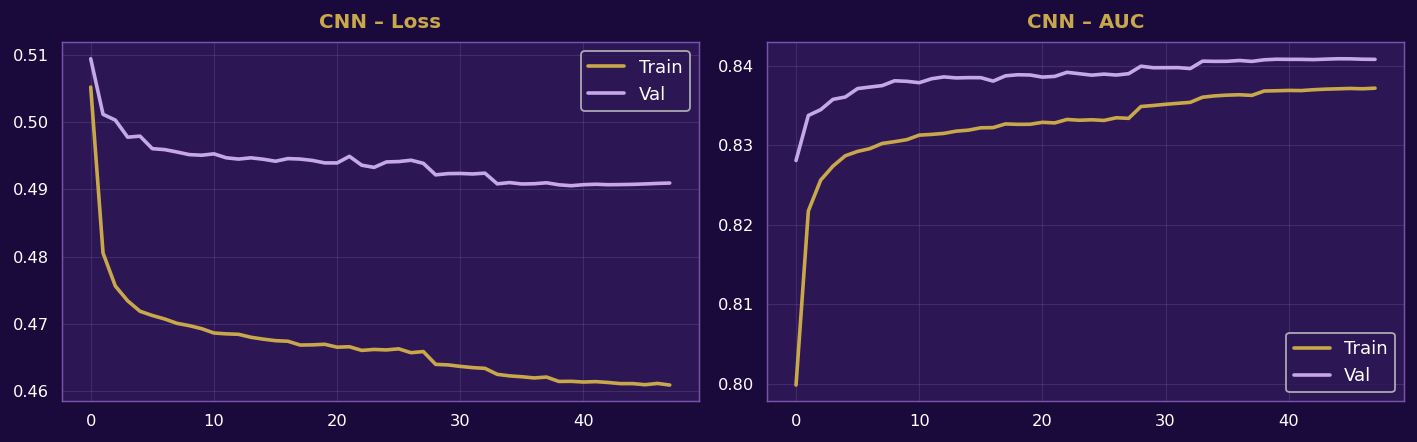


  CNN (1D Conv)
  AUC=0.8550 | F1=0.7942 | Acc=0.7762
  Precision=0.7953 | Recall=0.7930 | Specificity=0.7561
  Confusion Matrix: TP=72608 FP=18683 FN=18950 TN=57931
  Best Params:
{
  "filters": [
    32,
    16
  ],
  "kernel_size": 2,
  "dense_units": 32,
  "dropout": 0.3,
  "epochs_trained": 48
}


In [11]:
# ── 5. CNN ────────────────────────────────────────────────────────────────────
print("\n[5/7] Training: CNN (1D Conv) — up to", PROD_EPOCHS, "epochs...")

def build_cnn(seq_len, n_feat):
    inp = keras.Input(shape=(seq_len, n_feat))
    x = layers.Conv1D(32, kernel_size=2, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(16, kernel_size=2, padding="same", activation="relu")(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=[keras.metrics.AUC(name="auc")])
    return m

cnn_prod = build_cnn(SEQ_LEN, N_FEATURES_SEQ)
es_cnn = callbacks.EarlyStopping(monitor="val_loss", patience=ES_PATIENCE,
                                   restore_best_weights=True)
lr_cb  = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, verbose=0)
hist_cnn = cnn_prod.fit(
    X_tr_seq, y_tr_seq,
    validation_split=0.15, epochs=PROD_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[es_cnn, lr_cb], class_weight=cw_dl, verbose=0
)
plot_history(hist_cnn, "CNN")
yp_cnn, met_cnn = eval_keras_prod(cnn_prod, X_te_seq, y_te_seq, "CNN (1D Conv)",
    arch_params={"filters":[32,16],"kernel_size":2,"dense_units":32,
                 "dropout":0.30,"epochs_trained":len(hist_cnn.history["loss"])})
results["CNN (1D Conv)"] = dict(proba=yp_cnn, **met_cnn, color="#E74C3C",
                                 y_true=y_te_seq)



[6/7] Training: RNN (SimpleRNN) — up to 80 epochs...


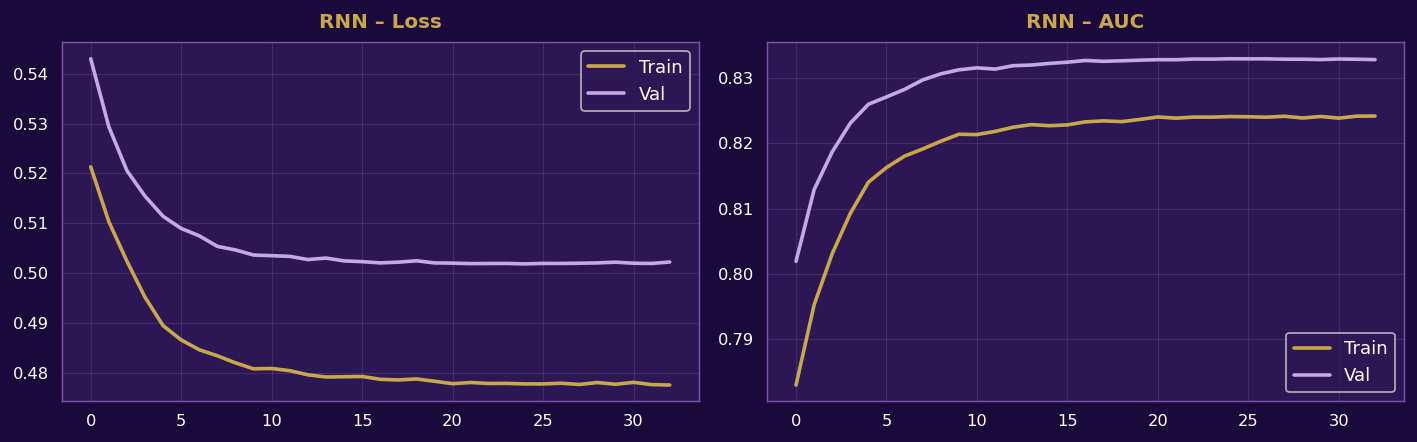


  RNN (SimpleRNN)
  AUC=0.8438 | F1=0.7896 | Acc=0.7740
  Precision=0.8005 | Recall=0.7791 | Specificity=0.7679
  Confusion Matrix: TP=71329 FP=17781 FN=20229 TN=58833
  Best Params:
{
  "rnn_units": [
    32,
    16
  ],
  "dense_units": 16,
  "dropout": 0.25,
  "epochs_trained": 33
}


In [12]:
# ── 6. RNN ────────────────────────────────────────────────────────────────────
print("\n[6/7] Training: RNN (SimpleRNN) — up to", PROD_EPOCHS, "epochs...")

def build_rnn(seq_len, n_feat):
    inp = keras.Input(shape=(seq_len, n_feat))
    x = layers.SimpleRNN(32, return_sequences=True)(inp)
    x = layers.Dropout(0.25)(x)
    x = layers.SimpleRNN(16)(x)
    x = layers.Dense(16, activation="relu")(x)
    x = layers.Dropout(0.25)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=[keras.metrics.AUC(name="auc")])
    return m

rnn_prod = build_rnn(SEQ_LEN, N_FEATURES_SEQ)
es_rnn = callbacks.EarlyStopping(monitor="val_loss", patience=ES_PATIENCE,
                                   restore_best_weights=True)
hist_rnn = rnn_prod.fit(
    X_tr_seq, y_tr_seq,
    validation_split=0.15, epochs=PROD_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[es_rnn, lr_cb], class_weight=cw_dl, verbose=0
)
plot_history(hist_rnn, "RNN")
yp_rnn, met_rnn = eval_keras_prod(rnn_prod, X_te_seq, y_te_seq, "RNN (SimpleRNN)",
    arch_params={"rnn_units":[32,16],"dense_units":16,"dropout":0.25,
                 "epochs_trained":len(hist_rnn.history["loss"])})
results["RNN (SimpleRNN)"] = dict(proba=yp_rnn, **met_rnn, color="#3498DB",
                                   y_true=y_te_seq)



[7/7] Training: LSTM (BiDirectional) — up to 80 epochs...


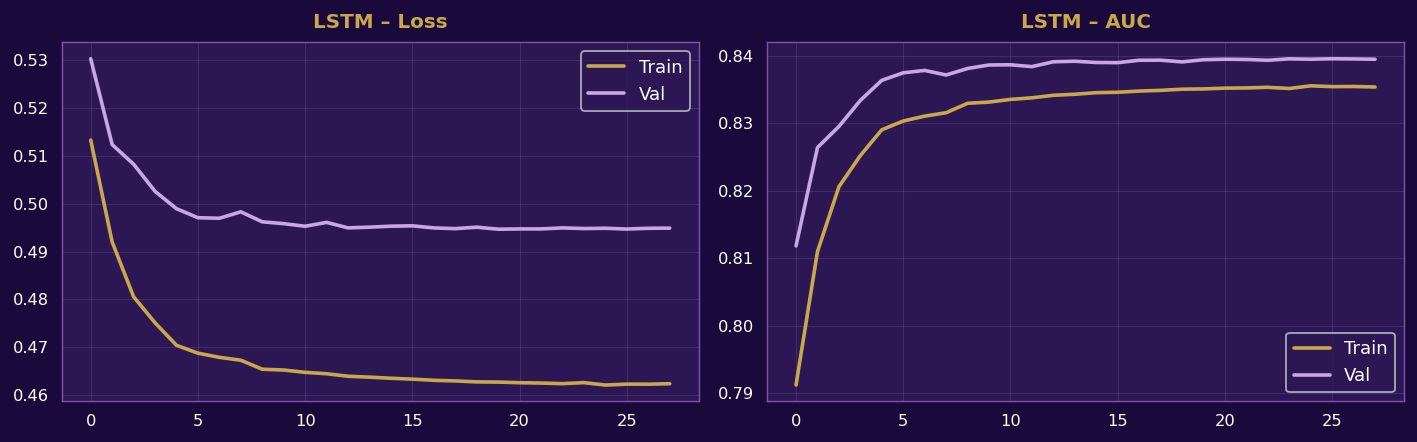


  LSTM (BiDir)
  AUC=0.8534 | F1=0.7910 | Acc=0.7742
  Precision=0.7973 | Recall=0.7849 | Specificity=0.7615
  Confusion Matrix: TP=71860 FP=18273 FN=19698 TN=58341
  Best Params:
{
  "bilstm_units": 32,
  "lstm_units": 16,
  "dense_units": [
    32,
    16
  ],
  "dropout": 0.25,
  "epochs_trained": 28
}


In [13]:
# ── 7. LSTM ───────────────────────────────────────────────────────────────────
print("\n[7/7] Training: LSTM (BiDirectional) — up to", PROD_EPOCHS, "epochs...")

def build_lstm(seq_len, n_feat):
    inp = keras.Input(shape=(seq_len, n_feat))
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(inp)
    x = layers.Dropout(0.25)(x)
    x = layers.LSTM(16)(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(5e-4),
              loss="binary_crossentropy",
              metrics=[keras.metrics.AUC(name="auc")])
    return m

lstm_prod = build_lstm(SEQ_LEN, N_FEATURES_SEQ)
es_lstm = callbacks.EarlyStopping(monitor="val_loss", patience=ES_PATIENCE,
                                    restore_best_weights=True)
hist_lstm = lstm_prod.fit(
    X_tr_seq, y_tr_seq,
    validation_split=0.15, epochs=PROD_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[es_lstm, lr_cb], class_weight=cw_dl, verbose=0
)
plot_history(hist_lstm, "LSTM")
yp_lstm, met_lstm = eval_keras_prod(lstm_prod, X_te_seq, y_te_seq, "LSTM (BiDir)",
    arch_params={"bilstm_units":32,"lstm_units":16,"dense_units":[32,16],
                 "dropout":0.25,"epochs_trained":len(hist_lstm.history["loss"])})
results["LSTM (BiDir)"] = dict(proba=yp_lstm, **met_lstm, color="#2ECC71",
                                y_true=y_te_seq)


---
## 📊 6. Production Leaderboard

  🏆 PRODUCTION LEADERBOARD – Full Dataset
  Model                              AUC      F1   Recall    Prec     Acc
--------------------------------------------------------------------
  CNN (1D Conv) *                   0.8550  0.7942   0.7930  0.7953  0.7762
  LSTM (BiDir) *                    0.8534  0.7910   0.7849  0.7973  0.7742
  MLP (sklearn)                     0.8462  0.7745   0.7865  0.7629  0.7718
  RNN (SimpleRNN) *                 0.8438  0.7896   0.7791  0.8005  0.7740
  XGBoost (Optuna)                  0.8437  0.7705   0.8190  0.7274  0.7568
  Random Forest                     0.8112  0.7370   0.7824  0.6967  0.7218
  Logistic Regression (L1)          0.7745  0.7157   0.7506  0.6839  0.7028
  * DL models evaluated on sequence test set (subset of full test)

  🏆 Champion: CNN (1D Conv) | AUC=0.8550


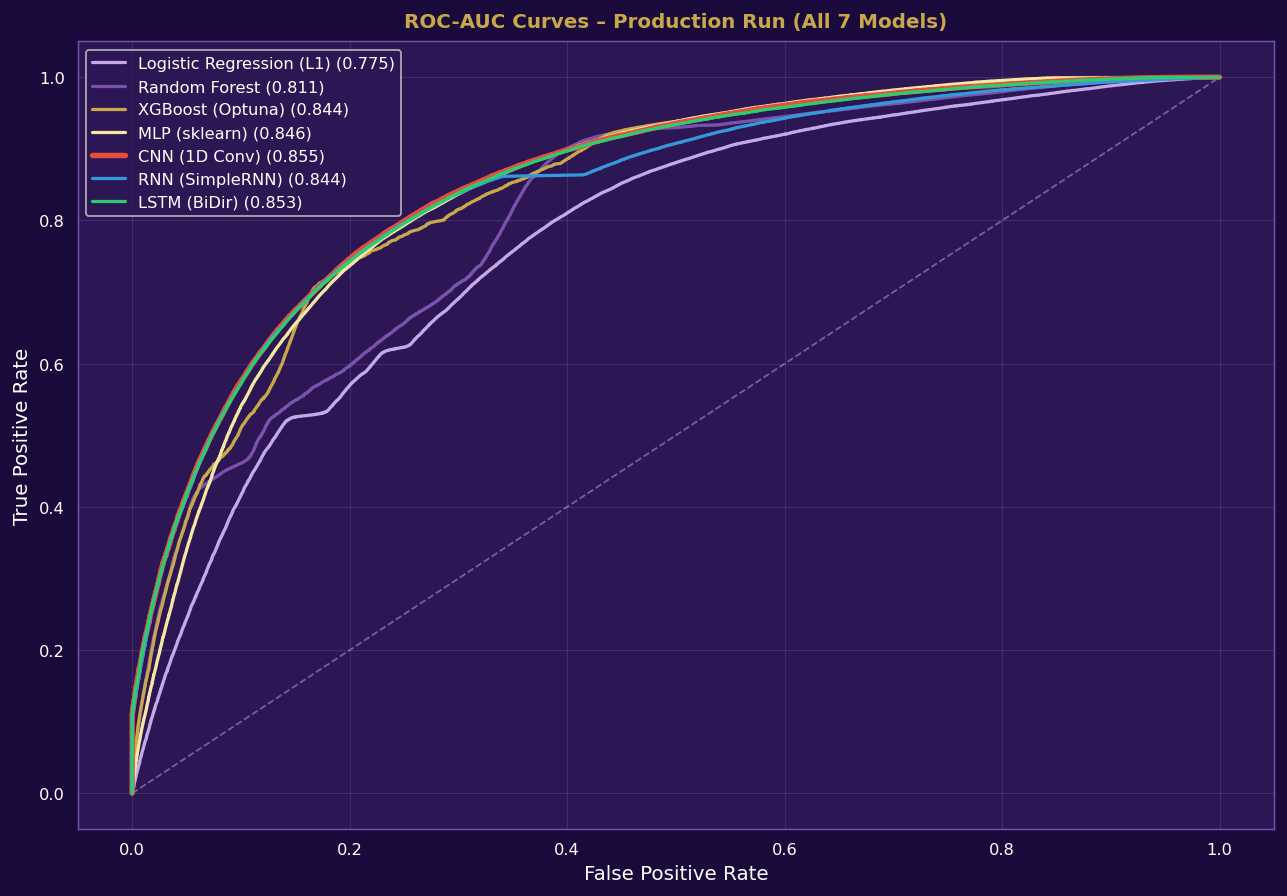


✅ Saved → model_metrics_production.csv


,Model,AUC,F1,Precision,Recall,Accuracy,Specificity,TP,FP,FN,TN
0,CNN (1D Conv),0.8550,0.7942,0.7953,0.7930,0.7762,0.7561,72608,18683,18950,57931
1,LSTM (BiDir),0.8534,0.7910,0.7973,0.7849,0.7742,0.7615,71860,18273,19698,58341
2,MLP (sklearn),0.8462,0.7745,0.7629,0.7865,0.7718,0.7571,89368,27780,24258,86589
3,RNN (SimpleRNN),0.8438,0.7896,0.8005,0.7791,0.7740,0.7679,71329,17781,20229,58833
4,XGBoost (Optuna),0.8437,0.7705,0.7274,0.8190,0.7568,0.6950,93064,34879,20562,79490
5,Random Forest,0.8112,0.7370,0.6967,0.7824,0.7218,0.6615,88900,38710,24726,75659
6,Logistic Regression (L1),0.7745,0.7157,0.6839,0.7506,0.7028,0.6553,85289,39423,28337,74946


In [14]:
import pandas as pd

# ─── Leaderboard ──────────────────────────────────────────────────────────────
print("=" * 68)
print("  🏆 PRODUCTION LEADERBOARD – Full Dataset")
print("=" * 68)
print(f"  {'Model':30s} {'AUC':>7} {'F1':>7} {'Recall':>8} {'Prec':>7} {'Acc':>7}")
print("-" * 68)
dl_models = {"CNN (1D Conv)","RNN (SimpleRNN)","LSTM (BiDir)"}
for name, r in sorted(results.items(), key=lambda x: x[1].get("AUC",0), reverse=True):
    note = " *" if name in dl_models else "  "
    print(f"  {name+note:32s} {r.get('AUC',0):>7.4f} {r.get('F1',0):>7.4f} "
          f"{r.get('Recall',0):>8.4f} {r.get('Precision',0):>7.4f} "
          f"{r.get('Accuracy',0):>7.4f}")
print("=" * 68)
print("  * DL models evaluated on sequence test set (subset of full test)")
champion_name = max(results, key=lambda n: results[n].get("AUC",0))
print(f"\n  🏆 Champion: {champion_name} | AUC={results[champion_name]['AUC']:.4f}")

# ─── ROC Curves ───────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, roc_auc_score
fig, ax = plt.subplots(figsize=(10, 7), facecolor=DLT["bg_dark"])
ax_style(ax, "ROC-AUC Curves – Production Run (All 7 Models)")
ax.plot([0,1],[0,1],"--",color=DLT["purple_light"],alpha=0.5,lw=1)

for name, r in results.items():
    y_true = r.get("y_true", y_test)   # DL uses y_te_seq
    fpr, tpr, _ = roc_curve(y_true, r["proba"])
    lw = 3 if name == champion_name else 1.8
    ax.plot(fpr, tpr, color=r["color"], lw=lw,
            label=f"{name} ({r.get('AUC',0):.3f})")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=9, facecolor=DLT["bg_card"], labelcolor=DLT["white"])
plt.tight_layout()
plt.savefig("roc_production.png", bbox_inches="tight", dpi=150, facecolor=DLT["bg_dark"])
plt.show()

# ─── Export Metrics CSV ───────────────────────────────────────────────────────
rows = []
for name, r in results.items():
    row = {"Model": name}
    for k in ["AUC","F1","Precision","Recall","Accuracy","Specificity","TP","FP","FN","TN"]:
        row[k] = round(r[k], 4) if k in r and isinstance(r[k], float) else r.get(k, "")
    rows.append(row)
df_metrics = pd.DataFrame(rows).sort_values("AUC", ascending=False).reset_index(drop=True)
df_metrics.to_csv("model_metrics_production.csv", index=False, encoding="utf-8-sig")
print("\n✅ Saved → model_metrics_production.csv")
display(df_metrics)


---
## 🔍 7. SHAP – Explainable AI (XGBoost Champion)

In [15]:
import shap
import matplotlib.pyplot as plt

# ─── Feature names ────────────────────────────────────────────────────────────
try:
    num_names = NUM_FEATS
    bin_names = BIN_FEATS
    cat_transformer = prep_prod.named_transformers_.get("cat", None)
    if cat_transformer and hasattr(cat_transformer, "named_steps"):
        ohe_names = cat_transformer.named_steps["ohe"].get_feature_names_out(CAT_FEATS).tolist()
    else:
        ohe_names = []
    feat_names_full = num_names + bin_names + ohe_names
    print(f"✅ Feature names: {len(feat_names_full)}")
except Exception as e:
    print(f"⚠️  {e}")
    feat_names_full = []

nf = X_te_prod.shape[1]
feat_names_full = feat_names_full[:nf] + [f"f_{i}" for i in range(len(feat_names_full), nf)]

# ─── SHAP TreeExplainer ───────────────────────────────────────────────────────
print("⏳ Computing SHAP values (XGBoost)...")
explainer = shap.TreeExplainer(xgb_prod)
N_SHAP    = min(2000, len(X_te_prod))
shap_vals = explainer.shap_values(X_te_prod[:N_SHAP])
print(f"✅ SHAP shape: {shap_vals.shape}")


✅ Feature names: 190
⏳ Computing SHAP values (XGBoost)...
✅ SHAP shape: (2000, 190)


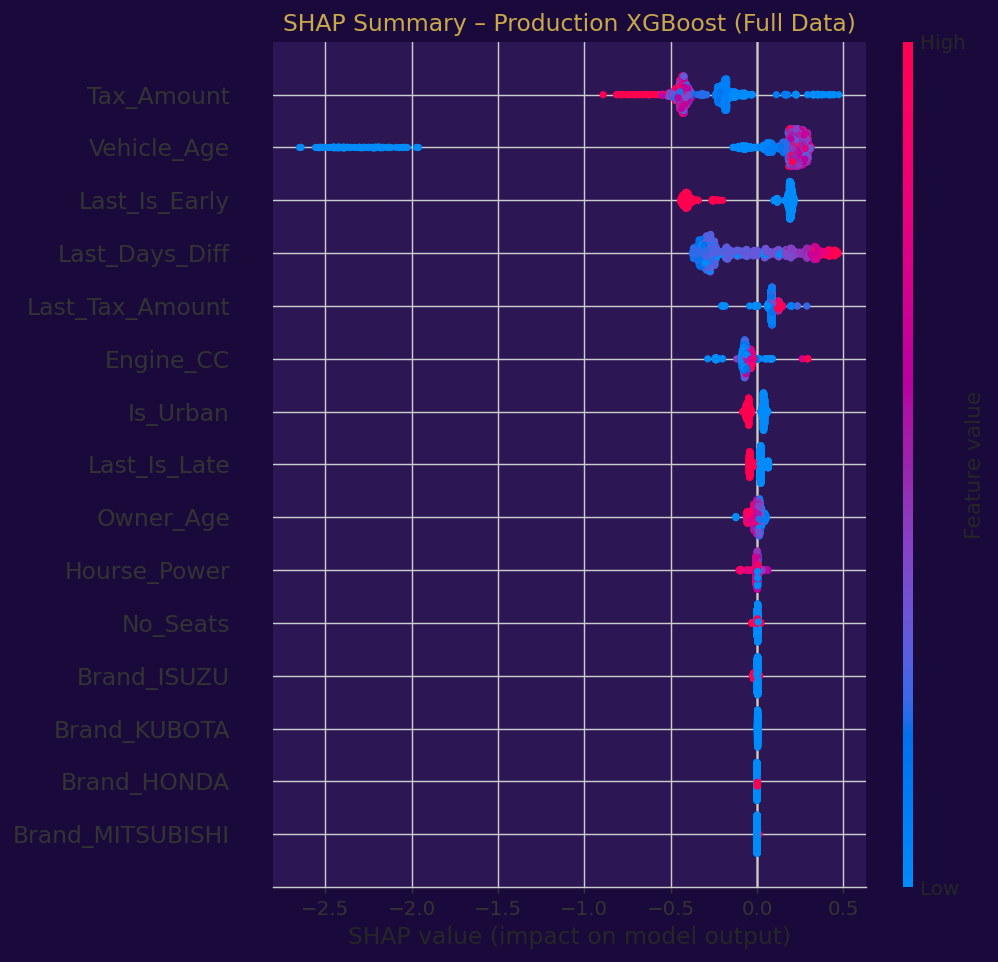

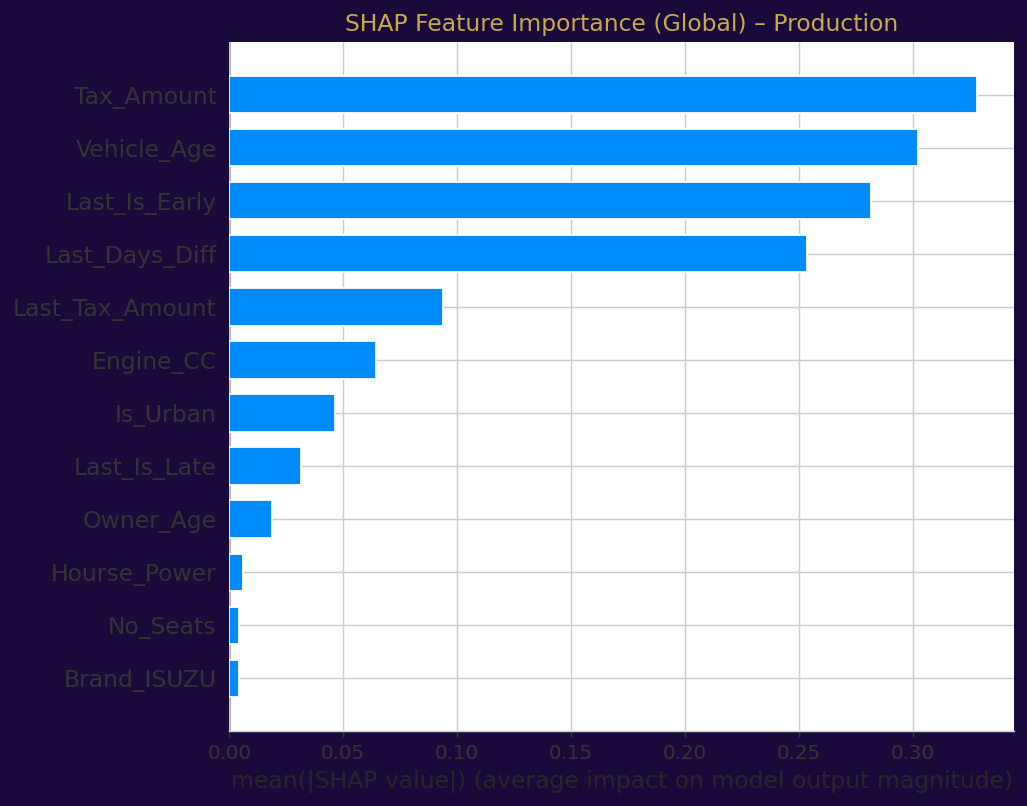

✅ SHAP plots saved


In [16]:
# ─── SHAP Summary Plot ────────────────────────────────────────────────────────
plt.figure(figsize=(10, 7), facecolor=DLT["bg_dark"])
plt.gca().set_facecolor(DLT["bg_card"])
shap.summary_plot(shap_vals, X_te_prod[:N_SHAP], feature_names=feat_names_full,
                  max_display=15, show=False)
plt.title("SHAP Summary – Production XGBoost (Full Data)",
          color=DLT["gold_main"], fontsize=13)
plt.tight_layout()
plt.savefig("shap_summary_production.png", bbox_inches="tight",
            dpi=150, facecolor=DLT["bg_dark"])
plt.show()

# ─── SHAP Bar ─────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 6), facecolor=DLT["bg_dark"])
shap.summary_plot(shap_vals, X_te_prod[:N_SHAP], feature_names=feat_names_full,
                  plot_type="bar", max_display=12, show=False)
plt.title("SHAP Feature Importance (Global) – Production",
          color=DLT["gold_main"], fontsize=13)
plt.tight_layout()
plt.savefig("shap_importance_production.png", bbox_inches="tight",
            dpi=150, facecolor=DLT["bg_dark"])
plt.show()
print("✅ SHAP plots saved")


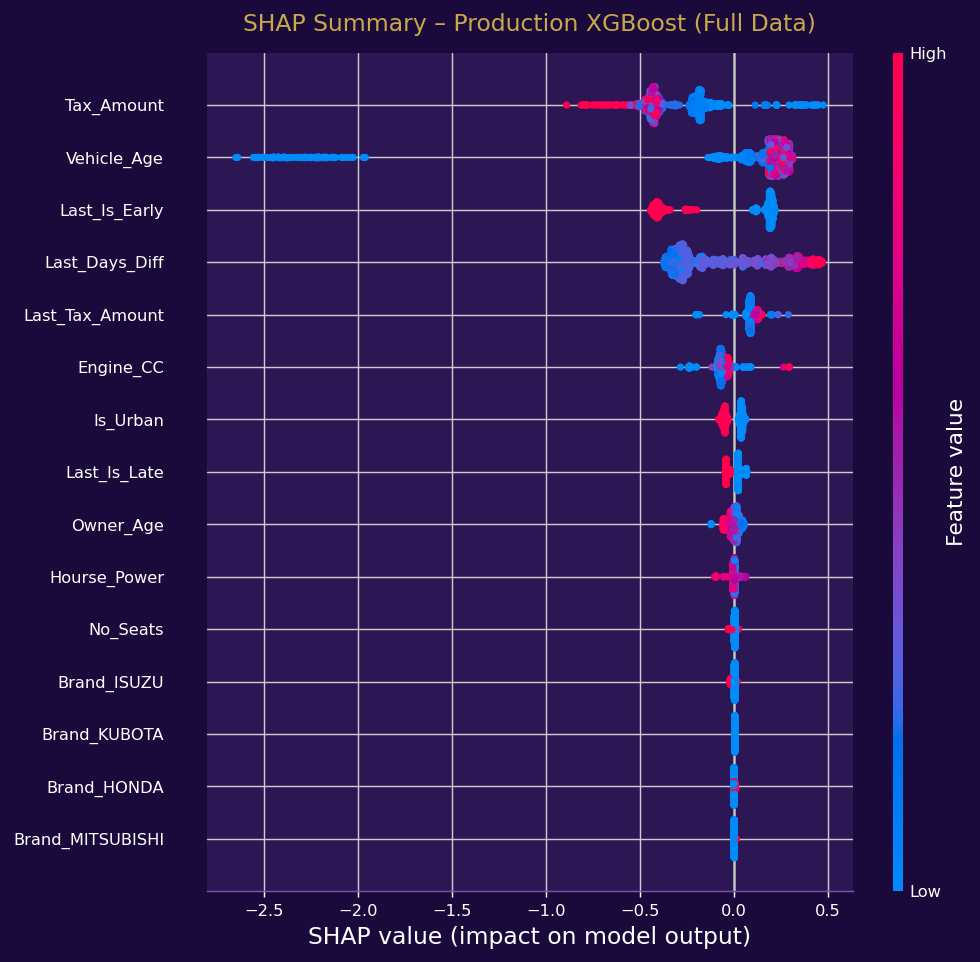

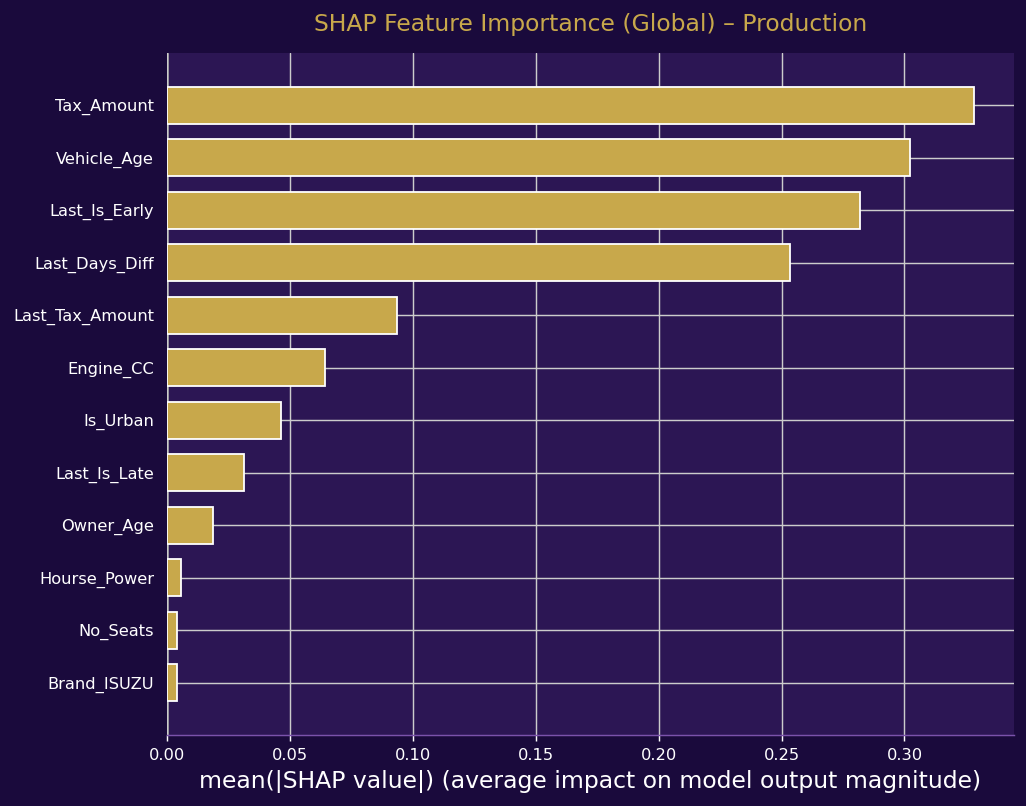

✅ SHAP plots saved


In [19]:
import matplotlib

# ─── Helper: force DLT colors onto current SHAP figure ───────────────────────
def style_shap_fig():
    fig = plt.gcf()
    fig.set_facecolor(DLT["bg_dark"])
    for ax in fig.get_axes():
        ax.set_facecolor(DLT["bg_card"])
        ax.tick_params(colors=DLT["white"], labelsize=9)
        ax.xaxis.label.set_color(DLT["white"])
        ax.yaxis.label.set_color(DLT["white"])
        if ax.get_title():
            ax.title.set_color(DLT["gold_main"])
        for spine in ax.spines.values():
            spine.set_edgecolor(DLT["purple_mid"])
        # Colorbar (ถ้ามี)
        for child in fig.get_children():
            if hasattr(child, 'yaxis'):
                child.yaxis.label.set_color(DLT["white"])
                child.tick_params(colors=DLT["white"])
    # Force all Text objects (y-tick labels ที่ SHAP วาดแบบ custom)
    for text in fig.findobj(matplotlib.text.Text):
        if text.get_text() not in ("", " "):
            current = text.get_color()
            # ถ้า SHAP ตั้ง default (ดำ/เทาเข้ม) → เปลี่ยนเป็นขาว
            if current in ("black", "#000000", "#333333", "k", (0,0,0,1)):
                text.set_color(DLT["white"])

# ─── SHAP Summary Plot (Beeswarm) ────────────────────────────────────────────
plt.figure(figsize=(10, 7), facecolor=DLT["bg_dark"])
plt.gca().set_facecolor(DLT["bg_card"])

# ตั้ง rcParams ชั่วคราวก่อนวาด ให้ SHAP รับสีจาก matplotlib
with matplotlib.rc_context({
    "text.color"       : DLT["white"],
    "axes.labelcolor"  : DLT["white"],
    "xtick.color"      : DLT["white"],
    "ytick.color"      : DLT["white"],
    "axes.facecolor"   : DLT["bg_card"],
    "figure.facecolor" : DLT["bg_dark"],
}):
    shap.summary_plot(shap_vals, X_te_prod[:N_SHAP],
                      feature_names=feat_names_full,
                      max_display=15, show=False)

style_shap_fig()   # ← patch สีที่ SHAP override ไป

plt.title("SHAP Summary – Production XGBoost (Full Data)",
          color=DLT["gold_main"], fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("shap_summary_production.png", bbox_inches="tight",
            dpi=150, facecolor=DLT["bg_dark"])
plt.show()

# ─── SHAP Bar Plot ───────────────────────────────────────────────────────────
plt.figure(figsize=(9, 6), facecolor=DLT["bg_dark"])
plt.gca().set_facecolor(DLT["bg_card"])

with matplotlib.rc_context({
    "text.color"       : DLT["white"],
    "axes.labelcolor"  : DLT["white"],
    "xtick.color"      : DLT["white"],
    "ytick.color"      : DLT["white"],
    "axes.facecolor"   : DLT["bg_card"],
    "figure.facecolor" : DLT["bg_dark"],
}):
    shap.summary_plot(shap_vals, X_te_prod[:N_SHAP],
                      feature_names=feat_names_full,
                      plot_type="bar", max_display=12,
                      color=DLT["gold_main"], show=False)

style_shap_fig()

plt.title("SHAP Feature Importance (Global) – Production",
          color=DLT["gold_main"], fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("shap_importance_production.png", bbox_inches="tight",
            dpi=150, facecolor=DLT["bg_dark"])
plt.show()
print("✅ SHAP plots saved")


---
## 📤 8. Export High-Risk Taxpayer List

In [17]:
import pandas as pd

# ─── Prediction Table (XGBoost on full test set) ─────────────────────────────
df_out = df_test[["Encode_ChassisNo","Encode_Plate","Province","Due_Year",
                   "Vehicle_Age","Owner_Age","Tax_Amount",
                   "Last_Is_Late","Target_Is_Late","Tax_Behavior_Segment",
                   "Seg_Code","Days_Late_Actual"]].copy().reset_index(drop=True)
df_out["P_Late_XGB"] = yp_xgb

def risk_tier(p):
    if p >= 0.70:   return "🔴 High Risk"
    elif p >= 0.50: return "🟠 Medium-High"
    elif p >= 0.30: return "🟡 Medium"
    else:           return "🟢 Low Risk"

df_out["Risk_Tier"] = df_out["P_Late_XGB"].apply(risk_tier)

print("Risk Tier Distribution:")
print(df_out["Risk_Tier"].value_counts().to_string())

# Export
high_risk = df_out[df_out["P_Late_XGB"] >= 0.5].sort_values("P_Late_XGB", ascending=False)
high_risk.to_csv("high_risk_taxpayers_production.csv", index=False, encoding="utf-8-sig")
df_out.to_csv("full_predictions_production.csv",       index=False, encoding="utf-8-sig")
print(f"\n✅ High-Risk: {len(high_risk):,} ราย ({len(high_risk)/len(df_out)*100:.1f}% ของ test set)")
print("✅ Saved → high_risk_taxpayers_production.csv")
print("✅ Saved → full_predictions_production.csv")
display(high_risk.head(10))


Risk Tier Distribution:
Risk_Tier
🟠 Medium-High    84152
🟡 Medium         56126
🟢 Low Risk       43926
🔴 High Risk      43791

✅ High-Risk: 127,943 ราย (56.1% ของ test set)
✅ Saved → high_risk_taxpayers_production.csv
✅ Saved → full_predictions_production.csv


,Encode_ChassisNo,Encode_Plate,Province,Due_Year,Vehicle_Age,Owner_Age,Tax_Amount,Last_Is_Late,Target_Is_Late,Tax_Behavior_Segment,Seg_Code,Days_Late_Actual,P_Late_XGB,Risk_Tier
113922,GKKKUIXKOJDVCII,YMVLICVCOSMUVEK,กรุงเทพมหานคร,2023,6.0,32.0,61.64,0,1,2. จ่ายล่าช้า (≤1 ปี),2,292,0.839508,🔴 High Risk
107927,FCBHRIMTTVQYYMI,HKHDMHPSTGANJXR,กรุงเทพมหานคร,2024,21.0,51.0,81.37,1,1,2. จ่ายล่าช้า (≤1 ปี),2,168,0.833114,🔴 High Risk
90559,PKWXNSUHXNOHNRD,DYHQJCITVNVSNXA,ขอนแก่น,2024,6.0,35.0,117.53,1,1,2. จ่ายล่าช้า (≤1 ปี),2,223,0.830111,🔴 High Risk
78271,MDAGFHJVVWFGMDN,WAQQMNFOPMHHBAR,ปราจีนบุรี,2024,25.0,54.0,84.66,1,1,2. จ่ายล่าช้า (≤1 ปี),2,160,0.820574,🔴 High Risk
92064,SMWMTJDVOYGYBIF,LGBFDLDAFYTGQFG,มุกดาหาร,2023,14.0,45.0,0.00,0,1,2. จ่ายล่าช้า (≤1 ปี),2,76,0.817194,🔴 High Risk
92065,SMWMTJDVOYGYBIF,LGBFDLDAFYTGQFG,มุกดาหาร,2024,15.0,45.0,0.00,0,1,2. จ่ายล่าช้า (≤1 ปี),2,272,0.817194,🔴 High Risk
115798,TZUIYKZJTQMCWWA,ZSCTLPIIIBEEEZY,กรุงเทพมหานคร,2023,18.0,37.0,103.97,1,1,2. จ่ายล่าช้า (≤1 ปี),2,114,0.813169,🔴 High Risk
80978,UJXYDPBOHGGXQMR,UFXKRWAPGXXNRBE,จันทบุรี,2024,20.0,31.0,105.62,1,1,2. จ่ายล่าช้า (≤1 ปี),2,109,0.811724,🔴 High Risk
227857,JAETLVGUUFJBTDU,HKWFHJTOUMCIJPM,กรุงเทพมหานคร,2023,6.0,67.0,68.50,0,0,1. จ่ายตรงเวลา/ล่วงหน้า,1,-2,0.811060,🔴 High Risk
111517,ETLMYLOAMXCHVTG,BJWTIUBSKBIQEUL,กรุงเทพมหานคร,2023,10.0,53.0,23.01,1,1,2. จ่ายล่าช้า (≤1 ปี),2,338,0.810686,🔴 High Risk


In [18]:
# ─── Final Run Summary ────────────────────────────────────────────────────────
print("=" * 65)
print("  🚗 VEHICLE TAX AI – PRODUCTION RUN COMPLETE")
print("=" * 65)
print(f"  Data     : Full dataset (Due_Year ≤ 2022 train | > 2022 test)")
print(f"  Train    : {len(X_train):,} | Test: {len(X_test):,}")
print(f"  Seq Test : {len(X_te_seq):,} (for CNN/RNN/LSTM)")
print()
print(f"  {'Model':30s} {'AUC':>7} {'F1':>7}")
print("  " + "-" * 42)
for name, r in sorted(results.items(), key=lambda x: x[1].get("AUC",0), reverse=True):
    champ = " ← CHAMPION" if name == champion_name else ""
    print(f"  {name:30s} {r.get('AUC',0):>7.4f} {r.get('F1',0):>7.4f}{champ}")
print("=" * 65)
print()
print("  📁 Output Files:")
for f in ["model_metrics_production.csv","high_risk_taxpayers_production.csv",
          "full_predictions_production.csv","roc_production.png",
          "shap_summary_production.png","shap_importance_production.png"]:
    print(f"     ✅ {f}")


  🚗 VEHICLE TAX AI – PRODUCTION RUN COMPLETE
  Data     : Full dataset (Due_Year ≤ 2022 train | > 2022 test)
  Train    : 742,221 | Test: 227,995
  Seq Test : 168,172 (for CNN/RNN/LSTM)

  Model                              AUC      F1
  ------------------------------------------
  CNN (1D Conv)                   0.8550  0.7942 ← CHAMPION
  LSTM (BiDir)                    0.8534  0.7910
  MLP (sklearn)                   0.8462  0.7745
  RNN (SimpleRNN)                 0.8438  0.7896
  XGBoost (Optuna)                0.8437  0.7705
  Random Forest                   0.8112  0.7370
  Logistic Regression (L1)        0.7745  0.7157

  📁 Output Files:
     ✅ model_metrics_production.csv
     ✅ high_risk_taxpayers_production.csv
     ✅ full_predictions_production.csv
     ✅ roc_production.png
     ✅ shap_summary_production.png
     ✅ shap_importance_production.png
